In [1]:
import os
import sys
import json
import matplotlib

import pandas as pd
import numpy as np
import anndata as ad
import scanpy as sc
import seaborn as sns
import sklearn.metrics
import tacco as tc
import time 
import tracemalloc 



In [2]:
path1='./inputQuery/'
path2='./inputRef/'

In [3]:
adseq = sc.read_h5ad(path2+'adata_raw.h5ad')
#adspa = sc.read_h5ad(path1+'sct_spatial.h5ad')
adspa=sc.read_10x_h5(path1+'cell_feature_matrix.h5')

#adspa.X =adspa.raw.X

print('count seq',adseq.X.toarray())
print('\n\ncount spatial',adspa.X)

print(adseq)
print(adspa)

/usr/local/Caskroom/mambaforge/base/envs/TACCO_env/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


count seq [[0 0 0 ... 0 0 6]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


count spatial <Compressed Sparse Row sparse matrix of dtype 'float32'
	with 801150 stored elements and shape (27547, 477)>
  Coords	Values
  (0, 4)	2.0
  (0, 7)	1.0
  (0, 16)	3.0
  (0, 24)	3.0
  (0, 40)	1.0
  (0, 46)	2.0
  (0, 48)	3.0
  (0, 69)	1.0
  (0, 70)	3.0
  (0, 71)	6.0
  (0, 72)	3.0
  (0, 81)	1.0
  (0, 82)	23.0
  (0, 88)	3.0
  (0, 90)	1.0
  (0, 93)	1.0
  (0, 101)	1.0
  (0, 104)	2.0
  (0, 109)	6.0
  (0, 123)	2.0
  (0, 146)	1.0
  (0, 163)	3.0
  (0, 184)	2.0
  (0, 186)	2.0
  (0, 208)	2.0
  :	:
  (27533, 379)	1.0
  (27533, 390)	1.0
  (27534, 46)	2.0
  (27534, 249)	1.0
  (27534, 289)	1.0
  (27535, 251)	1.0
  (27535, 375)	1.0
  (27536, 88)	2.0
  (27536, 121)	1.0
  (27536, 171)	1.0
  (27536, 314)	2.0
  (27536, 338)	1.0
  (27536, 356)	2.0
  (27538, 9)	1.0
  (27538, 171)	1.0
  (27538, 274)	1.0
  (27538, 362)	1.0
  (27538, 419)	1.0
  (27539, 313)	1.0
  (27540

In [ ]:
adseq=adseq[adseq.obs['sample'].isin(['C1','C2','C3','C4'])]
np.unique(adseq.obs['cell_type'])

array(['B.cell', 'B.prog', 'Defensin+.neutrophil', 'Endothelial',
       'Erythrocyte', 'FCGR3B+.neutrophil', 'GMP', 'HSC',
       'Infl.mesenchymal', 'LTF+.Neutrophil', 'MDP', 'MEP',
       'MMP9+.neutrophil', 'Macrophage', 'Mast.cell', 'Megakaryocyte',
       'Mesenchymal', 'Monocyte', 'Myeloma.mesenchymal', 'NP',
       'Osteolineage', 'SMC', 'T.cell', 'cDC', 'pDC'], dtype=object)

In [5]:
spdatapath='./inputQuery/'

coordinate1 = pd.read_csv(spdatapath+'cells.csv')
coordinate=coordinate1[['cell_id', 	'x_centroid', 	'y_centroid']].to_numpy()
np.array_equal(coordinate[:,0],adspa.obs_names)
adspa.obsm['spatial']=coordinate[:,1:].astype(float)

In [6]:
sc.pp.filter_cells(adspa, min_counts=5)
sc.pp.filter_cells(adseq, min_counts=5)
#sc.pp.filter_genes(adspa, min_cells=1)
sc.pp.filter_genes(adseq, min_cells=3)

print(adspa)
print(adseq)

/usr/local/Caskroom/mambaforge/base/envs/TACCO_env/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:158: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_counts"] = number


AnnData object with n_obs × n_vars = 16433 × 477
    obs: 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial'
AnnData object with n_obs × n_vars = 27822 × 38854
    obs: 'X', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'RNA_snn_res.0.5', 'seurat_clusters', 'cell_type', 'sample', 'cytopenia', 'n_counts'
    var: 'n_cells'


In [7]:
import matplotlib.pyplot as plt
import scipy.sparse
try:
   
    
    adspa_new = adspa
    adseq_new = adseq

    print("adspa_new shape:", adspa_new.shape)
    print("adseq_new shape:", adseq_new.shape)
    
    # Basic filtering
   
    sc.pp.filter_cells(adspa_new, min_counts=5)
    sc.pp.filter_cells(adseq_new, min_counts=5)
    sc.pp.filter_genes(adseq_new, min_cells=3)
    
    print("After filtering:")
    print("adspa_new shape:", adspa_new.shape)
    print("adseq_new shape:", adseq_new.shape)
    
    # Check for negative values in counts
    if scipy.sparse.issparse(adspa_new.X):
        has_negative = (adspa_new.X < 0).sum() > 0
    else:
        has_negative = (adspa_new.X < 0).any()
    
    print(f"\nData contains negative values: {has_negative}")
    
    # Create subset with common genes
          # Run TACCO with default parameters and assume_valid_counts
    tc.tl.annotate(adspa_new, adseq_new, 'cell_type', result_key='Tacco_annotation', 
                      assume_valid_counts=True, verbose=1)

    print("adspa_new.obs columns:", adspa_new.obs.columns.tolist())
    

        
   
except Exception as e:
    print(f"Error processing data: {e}")

adspa_new shape: (16433, 477)
adseq_new shape: (27822, 38854)


After filtering:
adspa_new shape: (16433, 477)
adseq_new shape: (27822, 38854)

Data contains negative values: False
Starting preprocessing
Annotation profiles were not found in `reference.varm["cell_type"]`. Constructing reference profiles with `tacco.preprocessing.construct_reference_profiles` and default arguments...
Finished preprocessing in 1.52 seconds.
Starting annotation of data with shape (16433, 450) and a reference of shape (27796, 450) using the following wrapped method:
+- platform normalization: platform_iterations=0, gene_keys=cell_type, normalize_to=adata
   +- multi center: multi_center=None multi_center_amplitudes=True
      +- bisection boost: bisections=4, bisection_divisor=3
         +- core: method=OT annotation_prior=None
mean,std( rescaling(gene) )  5.7624410036598785 27.423983800863425
bisection run on 1


/usr/local/Caskroom/mambaforge/base/envs/TACCO_env/lib/python3.12/site-packages/sparse_dot_mkl/_mkl_interface/__init__.py:147: RuntimeWarning: MKL_INTERFACE_LAYER value LP64,GNU invalid; set 'ILP64' or 'LP64'
  _warnings.warn(


bisection run on 0.6666666666666667
bisection run on 0.4444444444444444
bisection run on 0.2962962962962963
bisection run on 0.19753086419753085
bisection run on 0.09876543209876543
Finished annotation in 3.3 seconds.
adspa_new.obs columns: ['n_counts']


In [9]:
sc.experimental.pp.normalize_pearson_residuals(adspa_new,inplace=True) #ad_spatial_common.X[ad_spatial_common.X<0]=0
sc.pp.pca(adspa_new)
sc.pp.neighbors(adspa_new,n_pcs=30)
sc.tl.umap(adspa_new)
adspa_new.obsm['X_umap'] = adspa_new.obsm['X_umap']

/usr/local/Caskroom/mambaforge/base/envs/TACCO_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/usr/local/Caskroom/mambaforge/base/envs/TACCO_env/lib/python3.12/site-packages/tacco/plots/_plots.py:624: RuntimeWarning: invalid value encountered in divide
  weights = weights / weights.sum(axis=-1)[...,None]
/usr/local/Caskroom/mambaforge/base/envs/TACCO_env/lib/python3.12/site-packages/matplotlib/colors.py:2270: RuntimeWarning: invalid value encountered in cast
  i = (h * 6.0).astype(int)


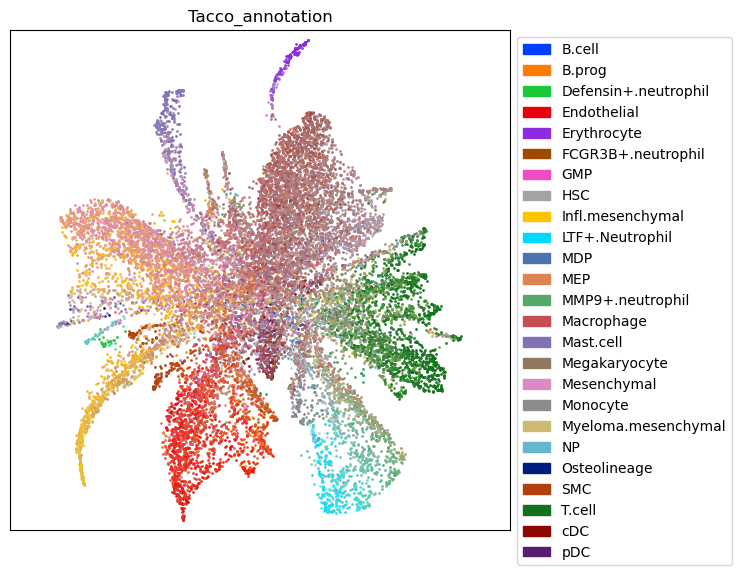

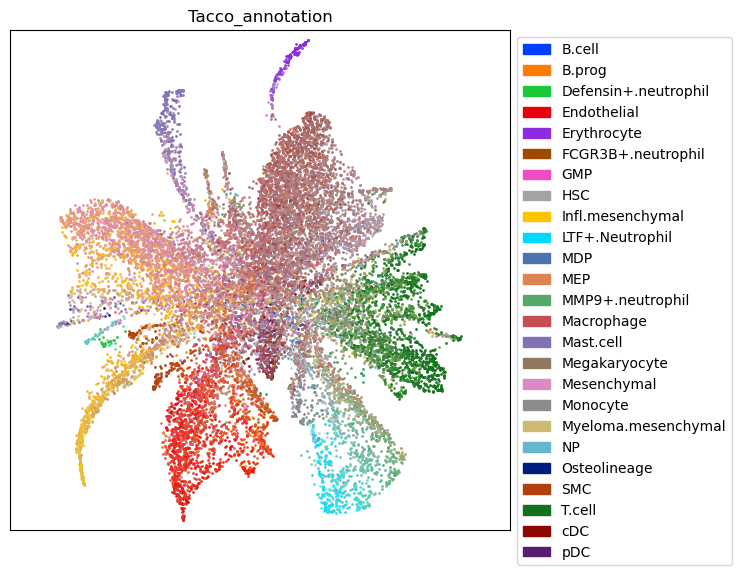

In [10]:
tc.pl.scatter(adspa_new, position_key='X_umap', keys='Tacco_annotation', joint=True, noticks=True, margin=0.1 )


In [12]:
import numpy as np

# get the fractions DataFrame
fractions = adspa_new.obsm['Tacco_annotation']

# take the cell type with the highest probability for each cell
pred_labels = fractions.idxmax(axis=1)

# store in .obs
adspa_new.obs['Tacco_pred_cell_type'] = pred_labels


In [13]:
adspa_new.write_h5ad('adspa_with_tacco_annotation.h5ad')

Creating highlight plots for 25 cell types...
  Saved B.cell (116 cells)
  Saved B.prog (1037 cells)
  Saved Defensin+.neutrophil (61 cells)
  Saved Endothelial (1069 cells)
  Saved Erythrocyte (119 cells)
  Saved FCGR3B+.neutrophil (155 cells)
  Saved GMP (370 cells)
  Saved HSC (192 cells)
  Saved Infl.mesenchymal (1613 cells)
  Saved LTF+.Neutrophil (378 cells)
  Saved MDP (694 cells)
  Saved MEP (214 cells)
  Saved MMP9+.neutrophil (453 cells)
  Saved Macrophage (1218 cells)
  Saved Mast.cell (345 cells)
  Saved Megakaryocyte (20 cells)
  Saved Mesenchymal (1856 cells)
  Saved Monocyte (2764 cells)
  Saved Myeloma.mesenchymal (113 cells)
  Saved NP (224 cells)
  Saved Osteolineage (56 cells)
  Saved SMC (324 cells)
  Saved T.cell (2038 cells)
  Saved cDC (693 cells)
  Saved pDC (311 cells)

All cell type UMAP plots have been saved to:
/Users/cheung/Documents/10x_analysis/xenium/analysis_Dec2025/cell_type_umaps
Combined grid plot saved to:
/Users/cheung/Documents/10x_analysis/xenium

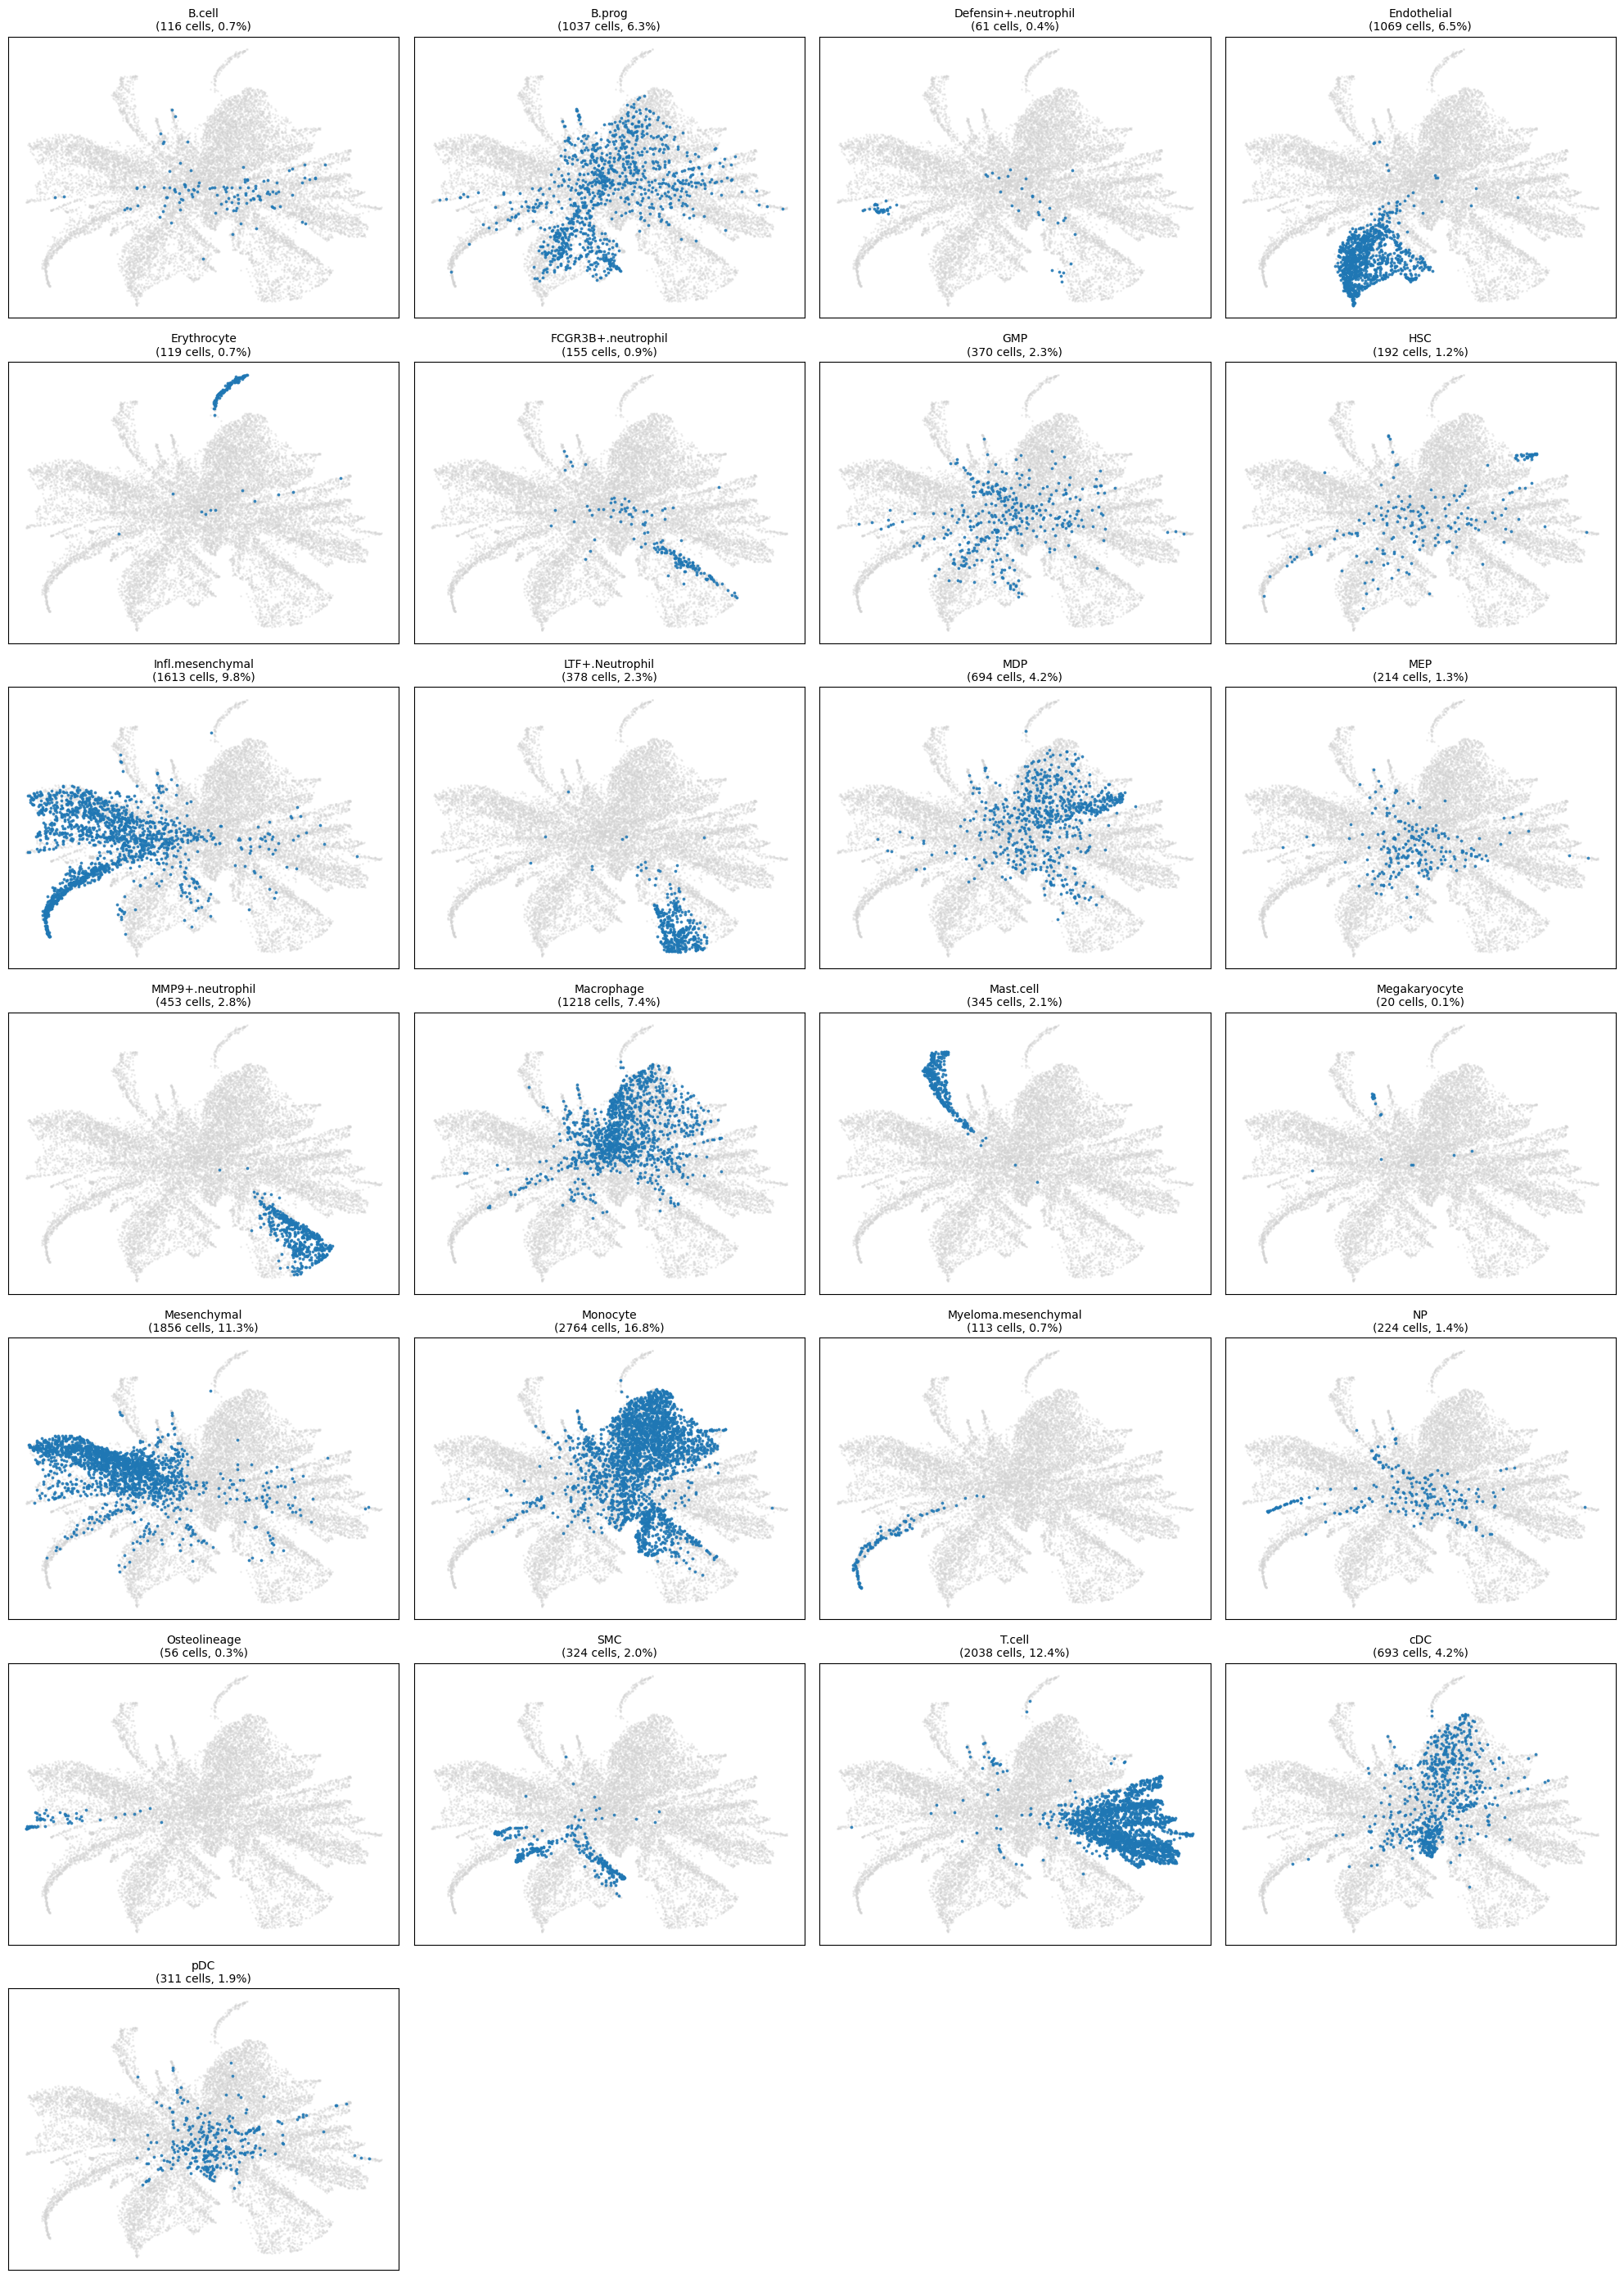

In [18]:
# Create UMAP plots highlighting each cell type
import matplotlib.pyplot as plt
import numpy as np
import os

# Check if the output directory exists, if not create it
output_dir = os.path.join(os.path.dirname(os.path.abspath('')), 'cell_type_umaps')
os.makedirs(output_dir, exist_ok=True)

# Get unique cell types
cell_types = sorted(adspa_new.obs['Tacco_pred_cell_type'].unique())
print(f"Creating highlight plots for {len(cell_types)} cell types...")

# Set up plotting parameters
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12

# Plot each cell type
for cell_type in cell_types:
    # Create a mask for the current cell type
    is_cell_type = adspa_new.obs['Tacco_pred_cell_type'] == cell_type
    
    # Count cells of this type
    cell_count = np.sum(is_cell_type)
    cell_pct = cell_count / len(adspa_new) * 100
    
    # Create the figure
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Get UMAP coordinates
    umap_coords = adspa_new.obsm['X_umap']
    
    # Plot background cells in light gray
    ax.scatter(umap_coords[:, 0], umap_coords[:, 1], 
              s=5, color='lightgray', alpha=0.3)
    
    # Highlight cells of the current type
    ax.scatter(umap_coords[is_cell_type, 0], umap_coords[is_cell_type, 1], 
              s=15, color='#1f77b4', alpha=0.8)
    
    # Set title and labels
    ax.set_title(f"UMAP: {cell_type}\n({cell_count} cells, {cell_pct:.1f}% of total)", fontsize=14)
    ax.set_xlabel('UMAP1', fontsize=12)
    ax.set_ylabel('UMAP2', fontsize=12)
    
    # Save the figure
    safe_name = ''.join(c if c.isalnum() else '_' for c in cell_type)
    fig_path = os.path.join(output_dir, f"umap_{safe_name}.png")
    plt.savefig(fig_path, bbox_inches='tight')
    
    # Display progress
    print(f"  Saved {cell_type} ({cell_count} cells)")
    
    # Close the figure to save memory
    plt.close(fig)

print(f"\nAll cell type UMAP plots have been saved to:\n{output_dir}")

# Create a combined figure with all cell types in a grid
n_cell_types = len(cell_types)
n_cols = min(4, n_cell_types)  # Maximum 4 plots per row
n_rows = int(np.ceil(n_cell_types / n_cols))

plt.figure(figsize=(5*n_cols, 4*n_rows))

for i, cell_type in enumerate(cell_types):
    # Create subplot
    plt.subplot(n_rows, n_cols, i+1)
    
    # Create a mask for the current cell type
    is_cell_type = adspa_new.obs['Tacco_pred_cell_type'] == cell_type
    
    # Count cells of this type
    cell_count = np.sum(is_cell_type)
    cell_pct = cell_count / len(adspa_new) * 100
    
    # Get UMAP coordinates
    umap_coords = adspa_new.obsm['X_umap']
    
    # Plot background cells in light gray
    plt.scatter(umap_coords[:, 0], umap_coords[:, 1], 
              s=1, color='lightgray', alpha=0.3)
    
    # Highlight cells of the current type
    plt.scatter(umap_coords[is_cell_type, 0], umap_coords[is_cell_type, 1], 
              s=3, color='#1f77b4', alpha=0.8)
    
    # Set title and remove ticks
    plt.title(f"{cell_type}\n({cell_count} cells, {cell_pct:.1f}%)", fontsize=10)
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
grid_path = os.path.join(output_dir, "all_cell_types_grid.png")
plt.savefig(grid_path, dpi=300, bbox_inches='tight')
print(f"Combined grid plot saved to:\n{grid_path}")